## O que este notebook faz

- **Coleta todas as perguntas bíblicas** com título, categoria e link.  
- **Armazena os dados em um DataFrame** do pandas.  
- **Analisa a quantidade de perguntas por categoria**.  
- **Gera a frequência de palavras** nos títulos das perguntas.  
- **Mostra uma nuvem de palavras** das perguntas.

                      Titulo        Categoria  \
0                             Estude a Bíblia   
1  Por Que Estudar a Bíblia?  Estude a Bíblia   
2                             Estude a Bíblia   
3  Como é um estudo bíblico?  Estude a Bíblia   
4                             Estude a Bíblia   

                                                Link  Titulo_len  Palavras  \
0  https://www.jw.org/pt/testemunhas-de-jeova/pec...           0         0   
1  https://www.jw.org/pt/testemunhas-de-jeova/pec...          25         5   
2  https://www.jw.org/pt/testemunhas-de-jeova/pec...           0         0   
3  https://www.jw.org/pt/testemunhas-de-jeova/pec...          25         5   
4  https://www.jw.org/pt/testemunhas-de-jeova/pec...           0         0   

  Subcategoria  
0       Outros  
1       Bíblia  
2       Outros  
3       Outros  
4       Outros  

Perguntas por Subcategoria:
 Subcategoria
Outros    5
Bíblia    1
Name: count, dtype: int64


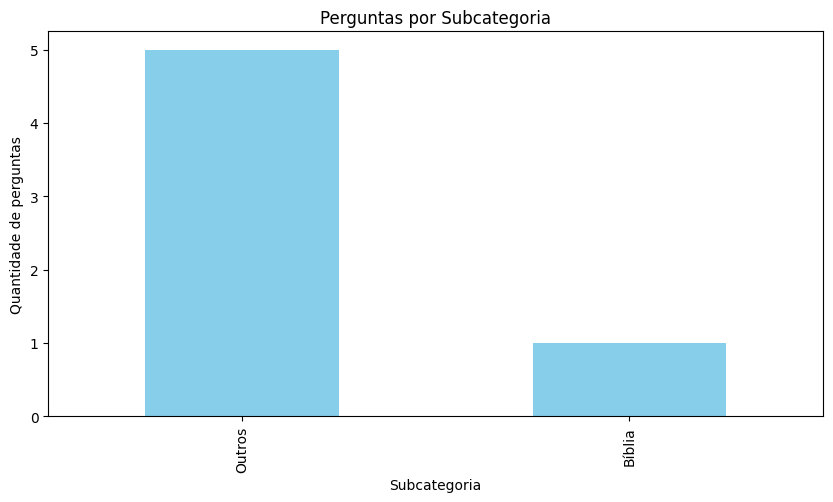


Palavras mais comuns nos títulos:
 [('por', 1), ('estudar', 1), ('bíblia', 1), ('como', 1), ('é', 1), ('estudo', 1), ('bíblico', 1), ('peça', 1), ('visita', 1)]


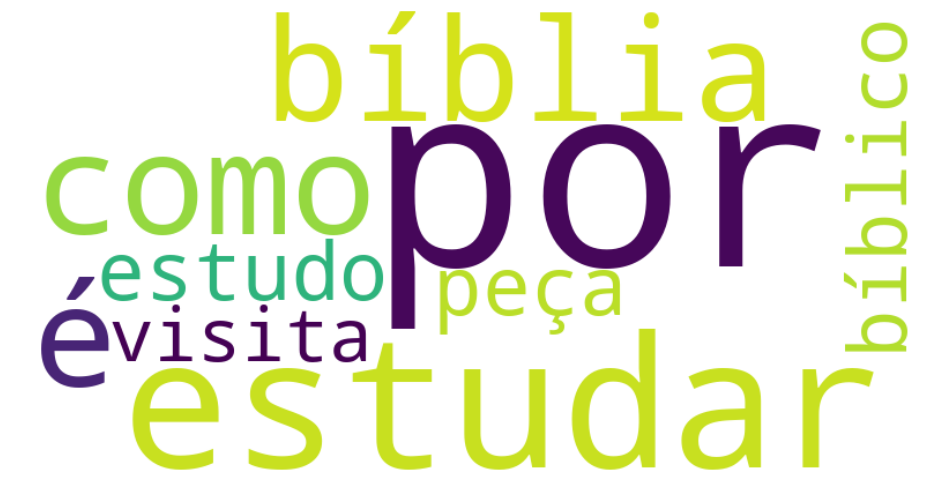

In [15]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
from collections import Counter
import re

# Importar matplotlib e wordcloud se disponíveis
try:
    import matplotlib.pyplot as plt
    from wordcloud import WordCloud
    HAS_PLOTTING = True
except ModuleNotFoundError:
    print("matplotlib ou wordcloud não instalados. Gráficos não serão gerados.")
    HAS_PLOTTING = False

# URL da página de perguntas bíblicas
url = "https://www.jw.org/pt/ensinos-biblicos/perguntas/"
response = requests.get(url)
if response.status_code != 200:
    raise Exception(f"Erro ao acessar a página: {response.status_code}")

soup = BeautifulSoup(response.text, "html.parser")

# Listas para coletar dados
titulos = []
categorias = []
links = []

# Extrair categorias reais da página (h2 visíveis)
categoria_headers = soup.find_all("h2")

for header in categoria_headers:
    categoria = header.text.strip()
    # Pegar todos os links <a> abaixo do header até o próximo <h2>
    for sibling in header.find_next_siblings():
        if sibling.name == "h2":
            break
        perguntas = sibling.find_all("a", href=True)
        for p in perguntas:
            titulo = p.text.strip()
            link = "https://www.jw.org" + p["href"]
            titulos.append(titulo)
            categorias.append(categoria)
            links.append(link)

# Montar DataFrame
df = pd.DataFrame({
    "Titulo": titulos,
    "Categoria": categorias,
    "Link": links
})

if df.empty:
    print("Nenhuma pergunta encontrada!")
else:
    # Novas colunas para análise
    df['Titulo_len'] = df['Titulo'].apply(len)
    df['Palavras'] = df['Titulo'].apply(lambda x: len(x.split()))
    
    # Criar subcategoria com base em palavras-chave
    def subcategoria(titulo):
        t = titulo.lower()
        if 'deus' in t:
            return 'Deus'
        elif 'jesus' in t:
            return 'Jesus'
        elif 'bíblia' in t:
            return 'Bíblia'
        elif 'vida' in t:
            return 'Vida'
        elif 'reino' in t:
            return 'Reino'
        else:
            return 'Outros'
    
    df['Subcategoria'] = df['Titulo'].apply(subcategoria)

    print(df.head())

    # Contagem de perguntas por subcategoria
    subcat_count = df['Subcategoria'].value_counts()
    print("\nPerguntas por Subcategoria:\n", subcat_count)

    # Gráfico de barras por subcategoria
    if HAS_PLOTTING and not subcat_count.empty:
        subcat_count.plot(kind='bar', figsize=(10,5), title="Perguntas por Subcategoria", color='skyblue')
        plt.xlabel("Subcategoria")
        plt.ylabel("Quantidade de perguntas")
        plt.show()

    # Frequência de palavras nos títulos (filtrando stopwords comuns)
    palavras = []
    stopwords = ['de','em','da','do','e','o','a','os','as','para','com','que','dos','das','um','uma']
    for titulo in df['Titulo']:
        palavras += re.findall(r'\w+', titulo.lower())

    palavras_filtradas = [w for w in palavras if w not in stopwords]
    frequencia = Counter(palavras_filtradas)
    print("\nPalavras mais comuns nos títulos:\n", frequencia.most_common(10))

    # Nuvem de palavras
    if HAS_PLOTTING:
        wordcloud = WordCloud(width=800, height=400, background_color="white").generate(" ".join(palavras_filtradas))
        plt.figure(figsize=(12,6))
        plt.imshow(wordcloud, interpolation="bilinear")
        plt.axis("off")
        plt.show()